In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

In [12]:
ds = xr.open_dataset('/cluster/scratch/vogtva/data/bruss/transfer2/_dataset.nc', engine='netcdf4')
ds

<xarray.Dataset> Size: 13GB
Dimensions:         (trajectory: 1000, component: 2, snapshot: 101, x: 128,
                     y: 128)
Coordinates:
  * component       (component) <U1 8B 'u' 'v'
  * snapshot        (snapshot) int64 808B 0 1 2 3 4 5 6 ... 95 96 97 98 99 100
  * trajectory      (trajectory) int64 8kB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
  * x               (x) int64 1kB 0 1 2 3 4 5 6 ... 121 122 123 124 125 126 127
  * y               (y) int64 1kB 0 1 2 3 4 5 6 ... 121 122 123 124 125 126 127
Data variables:
    A               (trajectory) float64 8kB ...
    B               (trajectory) float64 8kB ...
    Du              (trajectory) float64 8kB ...
    Dv              (trajectory) float64 8kB ...
    data            (trajectory, snapshot, component, x, y) float32 13GB ...
    input_filename  (trajectory) <U85 340kB ...
Attributes:
    timestep:     0.0025
    n_snapshots:  101
    n_x:          128
    n_y:          128
    dx:           1.0
    NCO:          netCDF Operators version 5.1.6 (Homepage = http://nco.sf.ne...
    history:      Tue Jul 15 21:28:55 2025: ncatted -a history,global,d,, /cl...

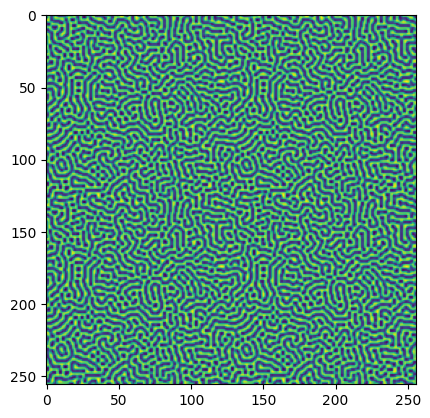

In [16]:
data = ds["data"]
j = np.random.randint(data.shape[0])
t = data[j, -1, 1]
n = t.shape[0]
arr = np.zeros((2*n,2*n))

arr[0:n,0:n] = t
arr[n:2*n,0:n] = t
arr[n:2*n,n:2*n] = t
arr[0:n,n:2*n] = t
plt.imshow(arr)